In [1]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [2]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [3]:
compact = True

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"data/compacted_{timestamp}.parquet")
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = os.path.join(d, "trash")
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading 2024-09-05_19-10-53.parquet
Reading 2024-09-05_18-55-06.parquet
Reading 2024-09-05_18-45-36.parquet
Reading 2024-09-05_19-04-41.parquet
Reading 2024-09-05_19-05-13.parquet
Reading compacted_20240905102810.parquet
Reading 2024-09-05_19-08-15.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
4475e400-dc9f-4421-b66c-817a5c06648f,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Nina Caliente],call,2,0.5866,0.017598,0,"[9, 6, 0, 0, 0]",800.0,NaN
b2810087-247b-4a4f-a3f3-61369c6d8663,4475e400-dc9f-4421-b66c-817a5c06648f,"[1, 39, 48]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Nina Caliente],raise,8,0.8114,0.032456,1,"[9, 6, 1, 0, 0]",800.0,NaN
8d753bc3-10dc-4dbc-a8e1-45b711711335,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Nina Caliente],call,2,0.5293,0.015879,0,"[7, 5, 0, 0, 0]",766.0,NaN
5182d838-46cd-42e6-9246-e57a28c20814,8d753bc3-10dc-4dbc-a8e1-45b711711335,[],"[96, 92]",0,"[4, 8]","[4, 8]","[True, True]","[False, False]",0,4,...,HumanPlayer,[Nina Caliente],call,4,0.5293,0.031758,0,"[7, 5, 0, 0, 0]",766.0,NaN
905c5945-c465-45c3-8fe2-e2d492f94b3c,5182d838-46cd-42e6-9246-e57a28c20814,"[37, 11, 46]","[92, 92]",0,"[0, 0]","[8, 8]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Nina Caliente],raise,8,0.7737,0.061896,2,"[11, 7, 5, 0, 0]",766.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,56832d49-3323-4a3c-b61a-d78f1cc32fad,"[27, 28, 1]","[78, 94]",0,"[0, 0]","[14, 14]","[False, False]","[False, False]",0,4,...,HumanPlayer,NaN,raise,30,0.5338,0.074732,1,"[1, 11, 6, 2, 0]",1153.0,NaN
e45b4fdd-5017-45b8-b839-87b08f5c264d,6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,"[27, 28, 1]","[48, 54]",0,"[30, 40]","[44, 54]","[True, True]","[False, False]",0,4,...,HumanPlayer,NaN,raise,48,0.5338,0.261562,1,"[1, 11, 6, 2, 0]",1153.0,NaN
d1170aa4-3098-4da3-aa8f-ebaef329d236,e45b4fdd-5017-45b8-b839-87b08f5c264d,"[27, 28, 1, 18]","[0, 16]",0,"[0, 0]","[92, 92]","[False, False]","[False, False]",0,4,...,HumanPlayer,NaN,check,0,0.4246,0.390632,1,"[1, 11, 6, 5, 0]",1153.0,NaN


In [5]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [6]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [7]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,game_id,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players
4475e400-dc9f-4421-b66c-817a5c06648f,0,0,0,0,0,0,0,0,0,0,...,1a53d0c3-e92c-4742-935e-0e3c35407852,call,2,0,0.5866,0.017598,preflop,Tord,Nina Caliente,2
b2810087-247b-4a4f-a3f3-61369c6d8663,0,0,0,0,0,2,0,0,0,0,...,1a53d0c3-e92c-4742-935e-0e3c35407852,raise,8,1,0.8114,0.032456,flop,Tord,Nina Caliente,2
8d753bc3-10dc-4dbc-a8e1-45b711711335,0,0,0,0,0,0,0,0,0,0,...,6909fb39-4283-4773-be9b-448cdfa3d634,call,2,0,0.5293,0.015879,preflop,Tord,Nina Caliente,2
5182d838-46cd-42e6-9246-e57a28c20814,0,0,0,0,0,2,0,0,0,0,...,6909fb39-4283-4773-be9b-448cdfa3d634,call,4,0,0.5293,0.031758,preflop,Tord,Nina Caliente,2
905c5945-c465-45c3-8fe2-e2d492f94b3c,0,0,0,0,0,6,0,0,0,0,...,6909fb39-4283-4773-be9b-448cdfa3d634,raise,8,1,0.7737,0.061896,flop,Tord,Nina Caliente,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,10,0,0,0,0,2,0,0,0,0,...,9987078c-1ed5-468f-9783-1e2cbc5ce27a,raise,30,0,0.5338,0.074732,flop,Arin,,2
e45b4fdd-5017-45b8-b839-87b08f5c264d,10,30,0,0,0,2,0,0,0,0,...,9987078c-1ed5-468f-9783-1e2cbc5ce27a,raise,48,0,0.5338,0.261562,flop,Arin,,2
d1170aa4-3098-4da3-aa8f-ebaef329d236,10,78,0,0,0,2,0,0,0,0,...,9987078c-1ed5-468f-9783-1e2cbc5ce27a,check,0,0,0.4246,0.390632,turn,Arin,,2
52c554f1-fb2c-41a6-ad56-de73fe010d10,10,78,0,0,0,2,0,0,0,0,...,9987078c-1ed5-468f-9783-1e2cbc5ce27a,check,0,0,0.2056,0.189152,river,Arin,,2


In [8]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [10]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [11]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players
4475e400-dc9f-4421-b66c-817a5c06648f,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Tord,Nina Caliente,2
b2810087-247b-4a4f-a3f3-61369c6d8663,0,0,0,0,0,2,0,0,0,0,...,1,0,0,0,raise,8,flop,Tord,Nina Caliente,2
8d753bc3-10dc-4dbc-a8e1-45b711711335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Tord,Nina Caliente,2
5182d838-46cd-42e6-9246-e57a28c20814,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,call,4,preflop,Tord,Nina Caliente,2
905c5945-c465-45c3-8fe2-e2d492f94b3c,0,0,0,0,0,6,0,0,0,0,...,1,0,0,0,raise,8,flop,Tord,Nina Caliente,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,10,0,0,0,0,2,0,0,0,0,...,0,0,0,0,raise,30,flop,Arin,,2
e45b4fdd-5017-45b8-b839-87b08f5c264d,10,30,0,0,0,2,0,0,0,0,...,0,0,0,0,raise,48,flop,Arin,,2
d1170aa4-3098-4da3-aa8f-ebaef329d236,10,78,0,0,0,2,0,0,0,0,...,0,0,0,0,check,0,turn,Arin,,2
52c554f1-fb2c-41a6-ad56-de73fe010d10,10,78,0,0,0,2,0,0,0,0,...,0,1,0,0,check,0,river,Arin,,2


In [12]:
y

4475e400-dc9f-4421-b66c-817a5c06648f    0.5866
b2810087-247b-4a4f-a3f3-61369c6d8663    0.8114
8d753bc3-10dc-4dbc-a8e1-45b711711335    0.5293
5182d838-46cd-42e6-9246-e57a28c20814    0.5293
905c5945-c465-45c3-8fe2-e2d492f94b3c    0.7737
                                         ...  
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e    0.5338
e45b4fdd-5017-45b8-b839-87b08f5c264d    0.5338
d1170aa4-3098-4da3-aa8f-ebaef329d236    0.4246
52c554f1-fb2c-41a6-ad56-de73fe010d10    0.2056
8af68bb6-2185-48e6-a703-98c22738aa2f    0.4610
Name: p, Length: 4672, dtype: float64

In [24]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [25]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (3746, 36)
Test shape: (926, 36)


In [26]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [27]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16199319614007932
MAE: 0.1255125408982797
MAPE: 29.73%


,y_test,y_pred
880581e5-8389-4186-8f30-827c3ffb81ef,0.6065,0.630699
53585779-3b38-4afa-82aa-f62a1f288adf,0.6065,0.480602
d4726d30-c16d-416a-9d80-78cec5b7f81b,0.8053,0.632032
e8471ae6-4685-4fae-903c-bc60a93955dc,0.3863,0.500450
17ddc421-ed54-4b8e-a543-d8c3f61166f2,0.3863,0.370948
...,...,...
03375f33-043c-4dbe-9717-875984a8fa0a,0.9514,0.484007
3d0b134e-3aa4-40bd-bade-7c2c7974bf42,0.4511,0.543306
d8246e10-4c9f-4061-8880-353777b4b5e4,0.2765,0.556179
a29812a0-8733-4f15-96ef-752a66da089c,0.2945,0.543063


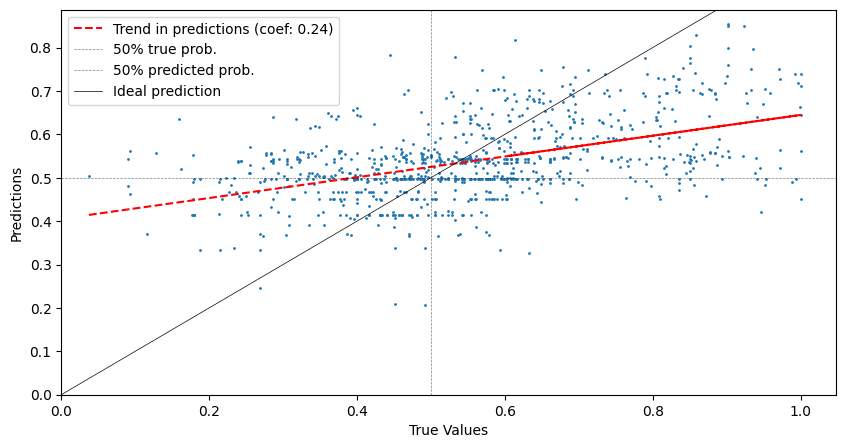

In [28]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [32]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
32,opponent_check_preflop,-7.645891e+11,7.645891e+11
12,call_preflop,7.645891e+11,7.645891e+11
31,opponent_call_showdown,-2.209178e+11,2.209178e+11
11,raise_showdown,2.209178e+11,2.209178e+11
36,opponent_check_showdown,-7.772360e+09,7.772360e+09
21,check_showdown,7.772360e+09,7.772360e+09
33,opponent_check_flop,6.006526e+09,6.006526e+09
13,call_flop,-6.006526e+09,6.006526e+09
34,opponent_check_turn,5.003788e+09,5.003788e+09
14,call_turn,-5.003788e+09,5.003788e+09
